# Natural Language Processing

### Disney Princesses Text Profiling: TF-IDF & Vector Similarity with spaCy

In [ ]:
# Instalamos/Descargamos el modelo en español de spaCy (necesario en Colab)
!python -m spacy download es_core_news_sm -q

import pandas as pd
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
import plotly.express as px
import numpy as np

# 1. Leer directamente desde tu repositorio en GitHub
url = 'https://raw.githubusercontent.com/XiomyDiazAnalyst/NLP-Projects/master/5.%20TFIDF/Princesas.csv'
data = pd.read_csv(url)

data.head()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 72.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


,Princesa,Personalidad
0,Blancanieves,Blancanieves es una princesa de noble cuna que...
1,Cenicienta,Cenicienta es inicialmente una sirvienta en su...
2,Aurora,"La Princesa Aurora, la Bella Durmiente, es la ..."
3,Bella,Bella es una muchacha que vive en la campiña f...
4,Jasmín,"Cuando se introdujo por primera vez, la Prince..."


## Pre-Procesamiento con spaCy
Tokenización y Lematización

In [ ]:
# Cargar el modelo de NLP en español
nlp = spacy.load("es_core_news_sm")

def pre_procesado_moderno(texto):
    # Le damos el texto con sus mayúsculas originales
    # para que spaCy pueda detectar los Nombres Propios (PROPN)
    doc = nlp(texto)

    tokens = []
    for token in doc:
        # Filtrar signos de puntuación, números y stop-words
        if token.is_alpha and not token.is_stop:

            # Si spaCy detecta que es un Nombre Propio, dejamos la palabra intacta pero en minúscula
            if token.pos_ == "PROPN":
                tokens.append(token.text.lower())
            # Si es cualquier otra palabra, usamos su lema (raíz real) en minúscula
            else:
                tokens.append(token.lemma_.lower())

    return " ".join(tokens)

# Aplicar la función
data['pre-procesado'] = data['Personalidad'].apply(pre_procesado_moderno)

# Ver la diferencia (ahora los nombres de las princesas deben salir perfectos)
data[['Princesa', 'pre-procesado']].head()

,Princesa,pre-procesado
0,Blancanieves,blancanieves princesa noble cuna ver forzado s...
1,Cenicienta,cenicienta inicialmente sirvienta casa constan...
2,Aurora,princesa aurora bella durmiente hija único rei...
3,Bella,bella muchacha vivir campiña francés padre inv...
4,Jasmín,introducir princesa jasmín décimo quinto cumpl...


## Matriz TF-IDF
Para medir cuán importante y relevante es una palabra dentro de un documento en comparación con una colección o conjunto de textos

In [ ]:
# Crear la matriz TF-IDF
tfidf_vect = TfidfVectorizer()
tfidf_matrix_sparse = tfidf_vect.fit_transform(data['pre-procesado'])

# Usamos get_feature_names_out() que es el estándar actual de sklearn
tfidf_matrix = pd.DataFrame(
    tfidf_matrix_sparse.toarray(),
    columns=tfidf_vect.get_feature_names_out(),
    index=data['Princesa'].values
)

tfidf_matrix.T.round(3).head(10)

,Blancanieves,Cenicienta,Aurora,Bella,Jasmín,Pocahontas,Mulan,Tiana,Mérida,Moana
abrumar,0.000,0.0,0.073,0.000,0.0,0.000,0.000,0.000,0.000,0.000
abuela,0.000,0.0,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.109
afortunado,0.099,0.0,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000
aislado,0.000,0.0,0.073,0.000,0.0,0.000,0.000,0.000,0.000,0.000
ajetreo,0.000,0.0,0.000,0.000,0.0,0.107,0.000,0.000,0.000,0.000
ajustar,0.000,0.0,0.000,0.000,0.0,0.000,0.137,0.000,0.000,0.000
aldea,0.000,0.0,0.000,0.092,0.0,0.000,0.000,0.000,0.000,0.000
alegre,0.085,0.0,0.000,0.000,0.0,0.091,0.000,0.000,0.000,0.000
algodón,0.000,0.0,0.000,0.000,0.0,0.000,0.000,0.000,0.098,0.000
alguien,0.000,0.0,0.000,0.000,0.0,0.091,0.000,0.117,0.000,0.000


## Distancia del Coseno y Visualización Interactiva
Medir qué tan diferentes son dos textos, palabras o documentos basándose en la orientación de sus vectores

In [ ]:
# Calcular distancia del coseno
dist_cos = cosine_distances(tfidf_matrix.values)
dist_cos_df = pd.DataFrame(dist_cos, columns=data['Princesa'].values, index=data['Princesa'].values)

# Visualización interactiva con Plotly
fig = px.imshow(
    dist_cos_df,
    text_auto='.2f',          # Mostrar valores con 2 decimales
    color_continuous_scale='Blues', # Mantener el color original pero más estilizado
    aspect="auto",
    title="Matriz de Distancia del Coseno entre Princesas (Interactiva)"
)

fig.update_layout(
    xaxis_title="Princesa",
    yaxis_title="Princesa",
    width=800, height=800
)

# ¡Pasa el mouse sobre la gráfica en Colab!
fig.show()

## Análisis

In [ ]:
# Extraemos el triángulo superior de la matriz para evitar duplicados (Ej: Bella-Aurora y Aurora-Bella) y la diagonal de ceros
mask = np.triu(np.ones(dist_cos_df.shape), k=1).astype(bool)
distancias_unicas = dist_cos_df.where(mask).stack().reset_index()
distancias_unicas.columns = ['Princesa 1', 'Princesa 2', 'Distancia']

# Ordenar de menor a mayor distancia
distancias_ordenadas = distancias_unicas.sort_values(by='Distancia')

print("👑 ¿Cuáles son las princesas más PARECIDAS? (Menor distancia)")
display(distancias_ordenadas.head(3))

print("\n⚔️ ¿Cuáles son las princesas más DIFERENTES? (Mayor distancia)")
display(distancias_ordenadas.tail(3).sort_values(by='Distancia', ascending=False))

👑 ¿Cuáles son las princesas más PARECIDAS? (Menor distancia)


,Princesa 1,Princesa 2,Distancia
17,Aurora,Bella,0.839748
1,Blancanieves,Aurora,0.865906
0,Blancanieves,Cenicienta,0.868630



⚔️ ¿Cuáles son las princesas más DIFERENTES? (Mayor distancia)


,Princesa 1,Princesa 2,Distancia
27,Bella,Tiana,1.000000
39,Mulan,Tiana,0.994545
40,Mulan,Mérida,0.994121


**Bella** y **Aurora** son las más parecidas con una distancia de 0.84 aprox.
Se observa una distancia de 1.00 entre princesas como **Tiana** y **Bella**. Esto indica que, una vez limpios los textos con spaCy, no comparten términos estadísticamente relevantes en la matriz TF-IDF.

##Palabras Clave Distintivas por Princesa (Interpretabilidad)

In [ ]:
# Extracción de las 5 palabras más representativas (mayor TF-IDF) por princesa
top_n = 5
keywords = {}

for princess in tfidf_matrix.index:
    top_words = tfidf_matrix.loc[princess].sort_values(ascending=False).head(top_n)
    keywords[princess] = ", ".join([f"{word} ({score:.2f})" for word, score in top_words.items()])

df_keywords = pd.DataFrame(list(keywords.items()), columns=['Princesa', 'Top 5 Palabras Clave (TF-IDF)'])

# Ajustar el estilo para dar más ancho a la columna de palabras clave
df_styled = df_keywords.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'normal'
}).set_table_styles([
    dict(selector='th.col1', props=[('min-width', '450px')]),
    dict(selector='td.col1', props=[('min-width', '450px')])
])

display(df_styled)

,Princesa,Top 5 Palabras Clave (TF-IDF)
0,Blancanieves,"grimhilde (0.30), reina (0.25), madrastra (0.25), importar (0.20), gruñón (0.20)"
1,Cenicienta,"cenicienta (0.32), realidad (0.32), esperanza (0.21), hermanastra (0.21), baile (0.21)"
2,Aurora,"hada (0.31), aurora (0.29), tía (0.22), durmiente (0.22), bella (0.19)"
3,Bella,"bella (0.39), mujer (0.31), hermoso (0.18), gustar (0.18), canción (0.18)"
4,Jasmín,"jasmín (0.37), cumpleaños (0.18), arrogante (0.18), décimo (0.18), ley (0.18)"
5,Pocahontas,"pocahontas (0.32), espíritu (0.21), altamente (0.21), naturaleza (0.18), película (0.11)"
6,Mulan,"honor (0.27), familia (0.27), traer (0.23), película (0.15), torpe (0.14)"
7,Tiana,"rana (0.41), convertir (0.35), naveen (0.28), camarera (0.28), vestido (0.28)"
8,Mérida,"mérida (0.39), pixar (0.29), cambiar (0.25), rizo (0.20), rebelde (0.20)"
9,Moana,"isla (0.33), recuperar (0.22), maui (0.22), moana (0.22), viaje (0.22)"


## Mapa 2D de Personalidades (PCA + Plotly)

In [ ]:
from sklearn.decomposition import PCA

# Reducir las dimensiones de la matriz TF-IDF a 2 componentes principales
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(tfidf_matrix.values)

# Crear DataFrame con coordenadas
df_pca = pd.DataFrame(componentes, columns=['Componente 1', 'Componente 2'], index=tfidf_matrix.index).reset_index()
df_pca.columns = ['Princesa', 'PC1', 'PC2']

# Gráfico interactivo en 2D
fig_pca = px.scatter(
    df_pca, x='PC1', y='PC2', text='Princesa',
    title='Mapa de Espacio Semántico de Princesas (Reducción PCA)',
    color='Princesa'
)

fig_pca.update_traces(textposition='top center', marker=dict(size=12))
fig_pca.update_layout(height=600, width=850, showlegend=False)
fig_pca.show()

Este mapa de espacio semántico obtenido mediante **PCA** (Análisis de Componentes Principales) proyecta la matriz TF-IDF multidimensional a solo dos dimensiones (PC1 y PC2). Nos permite interpretar visualmente cómo se agrupan las princesas según la narrativa de sus descripciones.
El algoritmo no conoce la historia de Disney ni el año de estreno de las películas; únicamente analiza la frecuencia de palabras. Sin embargo, mediante TF-IDF y PCA, reestructuró automáticamente la evolución histórica de las princesas de Disney de forma matemática.

## Agrupamiento Jerárquico (Dendrograma)

/tmp/ipykernel_4309/4006371194.py:5: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



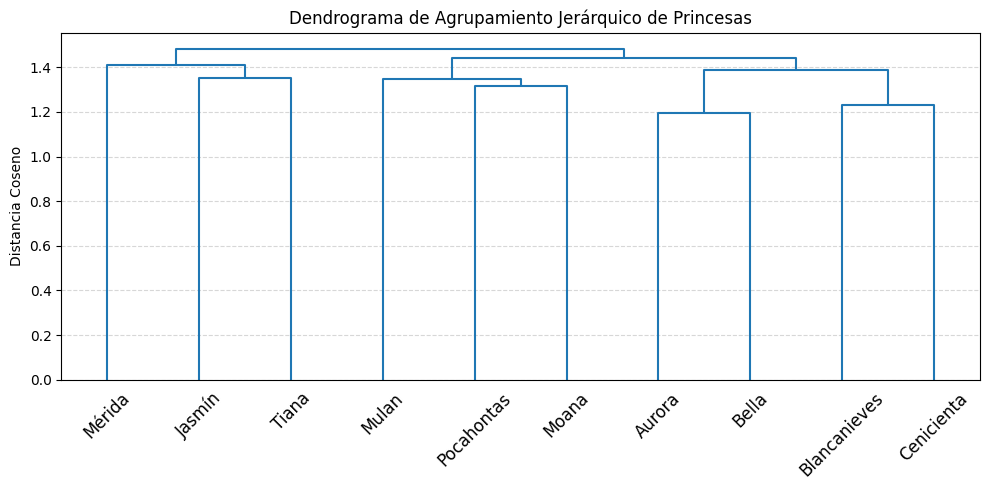

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Calcular agrupamiento jerárquico a partir de la matriz de distancias
enlace = linkage(dist_cos, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(
    enlace,
    labels=tfidf_matrix.index,
    orientation='top',
    leaf_rotation=45
)
plt.title('Dendrograma de Agrupamiento Jerárquico de Princesas')
plt.ylabel('Distancia Coseno')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

El árbol agrupa a las princesas en tres grandes familias bien definidas: las tradicionales/clásicas a la derecha, las heroínas de acción y naturaleza al centro, y las de alta autonomía personal a la izquierda.   

Máxima similitud clásica: **Aurora** y **Bella** (seguidas de **Blancanieves** y **Cenicienta**) forman las uniones a menor altura en el gráfico, confirmando matemáticamente que comparten el vocabulario más similar de todo el corpus.  